In [1]:
123

123

# 08-02. External Feature Ablation
## Transfer / Market Value / New-Team Environment

### 목적

08-01 v2에서 만든 leakage-safe preseason snapshot을 이용해
**외부 데이터가 실제로 다음 시즌 득점 예측에 추가 정보를 주는지** 검증합니다.

이번 Notebook에서는 **다시 HPO하지 않습니다.**

왜냐하면 지금 질문은:

> "CatBoost를 더 잘 튜닝할 수 있는가?"

가 아니라

> **"이적·시장가치·새 팀 환경 데이터가 기존 Exp9Cb보다 실제로 더 유용한가?"**

이기 때문입니다.

---

## 기준 모델

06에서 가장 강하고 안정적이었던 **고정 Baseline CatBoost**를 사용합니다.

- depth = 6
- learning_rate = 0.03
- loss = RMSE
- model-selection metric = MAE
- boosting iteration은 각 Outer Train 내부 마지막 시즌으로 early stopping 후 결정
- 나머지 hyperparameter는 고정

즉 실험마다 바뀌는 것은 **Feature Group뿐**입니다.

---

# 세 가지 실험군

## A. Market Value — target year 2005+

시장가치 coverage가 상대적으로 충분한 동일 표본에서 비교합니다.

```text
M0 Exp9Cb
M1 + Market Value
M2 + Market Value + Market Momentum
```

---

## B. Transfer — target year 2017+

exact transfer-date coverage가 과거보다 최근에 훨씬 좋기 때문에
이적 피처는 2017+ 동일 표본에서 비교합니다.

```text
T0 Exp9Cb
T1 + Transfer State
T2 + Transfer State + Transfer Economics
T3 + Transfer State + New-Team Environment
T4 + Transfer State + Economics + New-Team Environment
```

---

## C. Combined External Data — target year 2017+

```text
C0 Exp9Cb
C1 + Market Value + Momentum
C2 + Transfer + Economics + New-Team
C3 + ALL External Features
```

---

## 공통 평가

- Walk-forward MAE / RMSE / R²
- 평균 / 표준편차 / Worst Fold
- 10+ / 15+ / 20+ 고득점자
- 실제 preseason 팀 변경 선수
- 같은 팀 유지 선수
- 모델 Bias

### Test Lock

Final Test `2024-25 → 2025-26`는 계속 사용하지 않습니다.

## 0. 이번 Notebook의 해석 원칙

작은 MAE 차이 하나만 보고 "피처가 좋다"고 결론 내리지 않습니다.

예를 들어:

```text
전체 MAE        개선
이적 선수 MAE   크게 개선
고득점자 MAE    개선
Fold 안정성      유지
```

라면 의미 있는 외부 정보일 가능성이 높습니다.

반대로:

```text
평균 MAE 0.01 개선
특정 Fold만 크게 개선
나머지 Fold 악화
```

라면 안정적인 feature라고 보기 어렵습니다.

또한 이번 실험은 **고정 모델 ablation**입니다.

최종 feature set이 정해진 뒤에만
CatBoost/MLP 재검증 또는 HPO 재수행을 고려합니다.

In [2]:
from pathlib import Path
import json
import random
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

warnings.filterwarnings("ignore")

SEED = 42

def reset_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)

reset_seed()

print("Seed:", SEED)

Seed: 42


## 1. CatBoost 확인

In [3]:
try:
    import catboost
    from catboost import CatBoostRegressor

    print("catboost:", catboost.__version__)

except ImportError as exc:
    raise ImportError(
        "catboost가 필요합니다. `pip install catboost` 후 "
        "커널을 재시작하세요."
    ) from exc

catboost: 1.2.10


## 2. 08-01 v2 Snapshot 자동 탐색

기본 파일:

```text
artifacts/08_v2_preseason_player_snapshot_dev.csv
```

자동 탐색이 실패하면 `MANUAL_SNAPSHOT_PATH`에 직접 지정하면 됩니다.

In [4]:
MANUAL_SNAPSHOT_PATH = None

SEARCH_ROOTS = [
    Path.cwd(),
    Path.cwd().parent,
    Path.cwd().parent.parent,
]

SEARCH_ROOTS = list(
    dict.fromkeys(
        p.resolve()
        for p in SEARCH_ROOTS
        if p.exists()
    )
)

def find_snapshot():
    candidates = []

    for root in SEARCH_ROOTS:
        try:
            for path in root.rglob(
                "08_v2_preseason_player_snapshot_dev.csv"
            ):
                if path.is_file():
                    candidates.append(path)
        except (PermissionError, OSError):
            continue

    if not candidates:
        return None

    candidates.sort(
        key=lambda p: (
            len(str(p)),
            str(p),
        )
    )

    return candidates[0]


if MANUAL_SNAPSHOT_PATH is not None:
    SNAPSHOT_PATH = Path(
        MANUAL_SNAPSHOT_PATH
    )

else:
    SNAPSHOT_PATH = find_snapshot()


if (
    SNAPSHOT_PATH is None
    or not SNAPSHOT_PATH.exists()
):
    raise FileNotFoundError(
        "08_v2_preseason_player_snapshot_dev.csv를 찾지 못했습니다. "
        "MANUAL_SNAPSHOT_PATH에 직접 지정하세요."
    )

print("SNAPSHOT:", SNAPSHOT_PATH)

SNAPSHOT: D:\dev\03_PersonalProjects\next_season_goal_prediction\notebooks\artifacts\08_v2_preseason_player_snapshot_dev.csv


In [5]:
df = pd.read_csv(
    SNAPSHOT_PATH,
    low_memory=False,
)

print("Shape:", df.shape)
print(
    "Season:",
    df["season"].min(),
    "~",
    df["season"].max(),
)

print(
    "Target season:",
    df["target_season"].min(),
    "~",
    df["target_season"].max(),
)

print(
    "matched_next:"
)
display(
    df[
        "matched_next"
    ]
    .value_counts(
        dropna=False
    )
    .rename("n")
    .to_frame()
)

Shape: (23353, 114)
Season: 2000-2001 ~ 2023-2024
Target season: 2001-2002 ~ 2024-2025
matched_next:


,n
matched_next,
True,19403
False,3950


## 3. Final Test Lock

08-01 v2 development snapshot에는
Final Test input season `2024-2025`가 없어야 합니다.

In [6]:
LOCKED_TEST_INPUT_SEASON = "2024-2025"
LOCKED_TEST_TARGET_SEASON = "2025-2026"

assert (
    LOCKED_TEST_INPUT_SEASON
    not in set(
        df["season"].astype(str)
    )
)

print(
    "Locked Test:",
    LOCKED_TEST_INPUT_SEASON,
    "→",
    LOCKED_TEST_TARGET_SEASON,
)

print(
    "✅ Final Test is not loaded."
)

Locked Test: 2024-2025 → 2025-2026
✅ Final Test is not loaded.


# Part A. Exp9Cb 재생성

## 4. 과거 3시즌 scoring trend 재생성

08-01 snapshot은 외부 데이터 통합용이라
Exp9Cb의 rolling scoring feature는 다시 만듭니다.

### 중요한 점

각 선수의 현재 시즌 행에는:

```text
현재 시즌 goals 자체
+
현재 시즌 이전 최대 3시즌 기록
```

만 사용합니다.

`shift(1)`을 사용해 현재 시즌을 rolling history에 포함하지 않습니다.

In [7]:
df["season_start"] = (
    df["season"]
    .astype(str)
    .str[:4]
    .astype(int)
)

df["target_year"] = (
    df["target_season"]
    .astype(str)
    .str[:4]
    .astype(int)
)

df = (
    df
    .sort_values(
        [
            "player",
            "season_start",
        ]
    )
    .reset_index(drop=True)
)

player_group = (
    df.groupby(
        "player",
        sort=False,
    )
)

df[
    "goals_3yr_mean"
] = player_group[
    "goals"
].transform(
    lambda s:
        s.shift(1)
        .rolling(
            window=3,
            min_periods=1,
        )
        .mean()
)

df[
    "goals_per90_3yr_mean"
] = player_group[
    "goals_per90"
].transform(
    lambda s:
        s.shift(1)
        .rolling(
            window=3,
            min_periods=1,
        )
        .mean()
)

df[
    "goals_3yr_max"
] = player_group[
    "goals"
].transform(
    lambda s:
        s.shift(1)
        .rolling(
            window=3,
            min_periods=1,
        )
        .max()
)

HISTORICAL_COLS = [
    "goals_3yr_mean",
    "goals_per90_3yr_mean",
    "goals_3yr_max",
]

df[
    HISTORICAL_COLS
] = (
    df[
        HISTORICAL_COLS
    ]
    .fillna(0.0)
)

print(
    df[
        [
            "player",
            "season",
        ]
        + HISTORICAL_COLS
    ]
    .head(10)
)

            player     season  goals_3yr_mean  goals_per90_3yr_mean  \
0   Aaron Connolly  2019-2020        0.000000              0.000000   
1  Aaron Cresswell  2014-2015        0.000000              0.000000   
2  Aaron Cresswell  2016-2017        2.000000              0.052632   
3       Aaron Hunt  2006-2007        0.000000              0.000000   
4       Aaron Hunt  2008-2009        9.000000              0.487952   
5       Aaron Hunt  2009-2010        5.500000              0.324766   
6       Aaron Hunt  2010-2011        6.666667              0.333293   
7       Aaron Hunt  2011-2012        4.666667              0.218719   
8       Aaron Hunt  2012-2013        5.000000              0.221215   
9       Aaron Hunt  2013-2014        5.666667              0.245458   

   goals_3yr_max  
0            0.0  
1            0.0  
2            2.0  
3            0.0  
4            9.0  
5            9.0  
6            9.0  
7            9.0  
8            9.0  
9           11.0  


## 5. Conditional Regression 모집단

현재 Model B 문제 정의를 유지합니다.

> 다음 시즌에도 Big 5 기록이 존재하는 선수의 다음 시즌 Big 5 득점 수 예측

따라서 회귀 실험에서는:

```text
matched_next == True
```

만 사용합니다.

`matched_next`는 feature가 아니라 모집단 정의용 label입니다.

In [8]:
model_df = (
    df[
        df[
            "matched_next"
        ].eq(True)
    ]
    .copy()
)

model_df = (
    model_df
    .sort_values(
        [
            "season_start",
            "player",
        ]
    )
    .reset_index(drop=True)
)

print(
    "Conditional regression rows:",
    len(model_df),
)

print(
    "Target mean:",
    model_df[
        "next_goals"
    ].mean(),
)

Conditional regression rows: 19403
Target mean: 3.5985156934494666


## 6. 기존 Exp9Cb Feature

### Numeric 17개

기존 선수 성적 11개 + scoring history 3개 + 현재 팀 strength 3개입니다.

08-01 v2에서는 기존 팀 성적 이름이 `old_team_*`으로 저장되어 있습니다.

In [9]:
BASE_NUMERIC = [
    "age",
    "starts",
    "minutes",
    "goals",
    "assists",
    "non_penalty_goals",
    "penalty_goals",
    "penalty_attempts",
    "goals_per90",
    "assists_per90",
    "goal_contrib_per90",
]

TEAM_BASE_FEATURES = [
    "old_team_rank_pct",
    "old_team_points_per_game",
    "old_team_goal_diff_per_game",
]

EXP9CB_NUMERIC = (
    BASE_NUMERIC
    + HISTORICAL_COLS
    + TEAM_BASE_FEATURES
)

BASE_CATEGORICAL = [
    "league",
    "position_group",
]

TARGET = "next_goals"

print(
    "Exp9Cb numeric:",
    len(EXP9CB_NUMERIC),
)

print(
    "Categorical:",
    BASE_CATEGORICAL,
)

Exp9Cb numeric: 17
Categorical: ['league', 'position_group']


# Part B. External Feature Groups

## 7. Market Value Feature

08-01 v2 결과에서:

- 전체 coverage ≈ 68%
- target year 2005+ coverage ≈ 81%

이므로 Market Value 실험은 **동일한 2005+ 표본**에서 비교합니다.

In [10]:
MARKET_VALUE_FEATURES = [
    "market_value_known",
    "log_market_value",
    "market_value_percentile",
    "market_value_vs_position_median",
]

MARKET_MOMENTUM_FEATURES = [
    "market_value_growth_6m",
    "market_value_growth_12m",
    "market_value_vs_peak",
]

print(
    "Market core:",
    MARKET_VALUE_FEATURES,
)

print(
    "Market momentum:",
    MARKET_MOMENTUM_FEATURES,
)

Market core: ['market_value_known', 'log_market_value', 'market_value_percentile', 'market_value_vs_position_median']
Market momentum: ['market_value_growth_6m', 'market_value_growth_12m', 'market_value_vs_peak']


## 8. Transfer Feature

`unknown_date`나 `post_cutoff` audit는 사용하지 않습니다.

08-02에서는 의미가 비교적 명확한 feature부터 사용합니다.

### State
- 실제 cutoff 시점 팀 변경 여부
- 같은 리그 이적 여부
- 리그/국가 변경
- 임대 여부
- 이적 후 cutoff까지 경과 일수

### Economics
- fee 존재 여부
- log transfer fee
- fee / market value

### New-Team Environment
- 새 팀의 직전 시즌 strength
- 현재 팀 대비 환경 변화

`destination_in_big5`는 이번 Model B 회귀에서는 제외합니다.
이 피처는 이후 Model A Big5 잔류 분류에서 더 직접적으로 활용할 예정입니다.

In [11]:
TRANSFER_STATE_FEATURES = [
    "changed_team_preseason",
    "same_league_transfer",
    "league_changed",
    "country_changed",
    "is_loan_preseason",
    "days_since_transfer",
]

TRANSFER_ECONOMIC_FEATURES = [
    "transfer_fee_known",
    "log_transfer_fee",
    "fee_to_transfer_market_value_ratio",
]

NEW_TEAM_ENVIRONMENT_FEATURES = [
    "new_team_prev_rank_pct",
    "new_team_prev_points_per_game",
    "new_team_prev_goal_diff_per_game",
    "team_rank_change",
    "team_points_change",
    "team_goal_diff_change",
    "new_team_strength_missing",
]

print(
    "Transfer state:",
    TRANSFER_STATE_FEATURES,
)

print(
    "Transfer economics:",
    TRANSFER_ECONOMIC_FEATURES,
)

print(
    "New team:",
    NEW_TEAM_ENVIRONMENT_FEATURES,
)

Transfer state: ['changed_team_preseason', 'same_league_transfer', 'league_changed', 'country_changed', 'is_loan_preseason', 'days_since_transfer']
Transfer economics: ['transfer_fee_known', 'log_transfer_fee', 'fee_to_transfer_market_value_ratio']
New team: ['new_team_prev_rank_pct', 'new_team_prev_points_per_game', 'new_team_prev_goal_diff_per_game', 'team_rank_change', 'team_points_change', 'team_goal_diff_change', 'new_team_strength_missing']


## 9. External Feature Missingness 확인

In [12]:
ALL_EXTERNAL_FEATURES = (
    MARKET_VALUE_FEATURES
    + MARKET_MOMENTUM_FEATURES
    + TRANSFER_STATE_FEATURES
    + TRANSFER_ECONOMIC_FEATURES
    + NEW_TEAM_ENVIRONMENT_FEATURES
)

missingness = (
    model_df[
        ALL_EXTERNAL_FEATURES
    ]
    .isna()
    .mean()
    .sort_values(
        ascending=False
    )
    .rename("missing_rate")
    .to_frame()
)

missingness

,missing_rate
fee_to_transfer_market_value_ratio,0.943720
log_transfer_fee,0.943669
days_since_transfer,0.943153
market_value_growth_12m,0.316601
market_value_growth_6m,0.296397
market_value_vs_position_median,0.295006
log_market_value,0.295006
market_value_percentile,0.295006
market_value_vs_peak,0.295006
team_goal_diff_change,0.013915


# Part C. Walk-forward Evaluation

## 10. Outer Fold 고정

05~07에서 사용한 것과 같은 4개 시즌을 유지합니다.

```text
Fold 1: 2020-21
Fold 2: 2021-22
Fold 3: 2022-23
Fold 4: 2023-24
```

In [13]:
OUTER_VAL_SEASONS = [
    "2020-2021",
    "2021-2022",
    "2022-2023",
    "2023-2024",
]

print(
    "Outer validation seasons:",
    OUTER_VAL_SEASONS,
)

Outer validation seasons: ['2020-2021', '2021-2022', '2022-2023', '2023-2024']


## 11. Metrics

고득점자뿐 아니라 이번 external feature의 핵심 대상인
**실제 preseason 팀 변경 선수**도 따로 봅니다.

In [14]:
def regression_metrics(
    y_true,
    y_pred,
):
    y_true = np.asarray(
        y_true,
        dtype=float,
    )

    y_pred = np.asarray(
        y_pred,
        dtype=float,
    )

    return {
        "mae": mean_absolute_error(
            y_true,
            y_pred,
        ),
        "rmse": (
            mean_squared_error(
                y_true,
                y_pred,
            ) ** 0.5
        ),
        "r2": r2_score(
            y_true,
            y_pred,
        ),
        "bias": float(
            np.mean(
                y_pred - y_true
            )
        ),
    }


def slice_metrics(
    y_true,
    y_pred,
    mask,
):
    y_true = np.asarray(
        y_true,
        dtype=float,
    )

    y_pred = np.asarray(
        y_pred,
        dtype=float,
    )

    mask = np.asarray(
        mask,
        dtype=bool,
    )

    if mask.sum() == 0:
        return {
            "n": 0,
            "mae": np.nan,
            "bias": np.nan,
            "actual_mean": np.nan,
            "pred_mean": np.nan,
        }

    return {
        "n": int(
            mask.sum()
        ),
        "mae": mean_absolute_error(
            y_true[mask],
            y_pred[mask],
        ),
        "bias": float(
            np.mean(
                y_pred[mask]
                - y_true[mask]
            )
        ),
        "actual_mean": float(
            np.mean(
                y_true[mask]
            )
        ),
        "pred_mean": float(
            np.mean(
                y_pred[mask]
            )
        ),
    }

## 12. CatBoost 데이터 준비

CatBoost는 categorical feature를 native 방식으로 사용합니다.

각 Fold에 들어가는 **feature 정보는 실험 정의만 다르고**
모델의 학습 규칙은 동일합니다.

In [15]:
def prepare_catboost_xy(
    data,
    numeric_features,
):
    feature_cols = (
        numeric_features
        + BASE_CATEGORICAL
    )

    X = data[
        feature_cols
    ].copy()

    for col in BASE_CATEGORICAL:
        X[col] = (
            X[col]
            .fillna(
                "__MISSING__"
            )
            .astype(str)
        )

    # 숫자형은 CatBoost가 NaN 처리 가능
    for col in numeric_features:
        X[col] = pd.to_numeric(
            X[col],
            errors="coerce",
        )

    y = (
        data[
            TARGET
        ]
        .to_numpy(
            dtype=np.float32
        )
    )

    cat_indices = [
        X.columns.get_loc(c)
        for c in BASE_CATEGORICAL
    ]

    return (
        X,
        y,
        cat_indices,
    )

## 13. 고정 Baseline CatBoost

06 설정을 유지합니다.

중요:

- hyperparameter tuning 없음
- Outer Validation을 early stopping에 사용하지 않음
- Outer Train의 마지막 시즌만 calibration validation으로 사용
- calibration에서 iteration 수를 정한 뒤 Outer Train 전체 재학습

In [16]:
CATBOOST_MAX_ITER = 2000
CATBOOST_PATIENCE = 50

FIXED_CATBOOST_PARAMS = {
    "depth": 6,
    "learning_rate": 0.03,
    "loss_function": "RMSE",
}


def fit_fixed_catboost(
    outer_train_df,
    outer_val_df,
    numeric_features,
    seed,
):
    calibration_val_start = (
        outer_train_df[
            "season_start"
        ].max()
    )

    calibration_train_df = (
        outer_train_df[
            outer_train_df[
                "season_start"
            ]
            < calibration_val_start
        ]
        .copy()
    )

    calibration_val_df = (
        outer_train_df[
            outer_train_df[
                "season_start"
            ]
            == calibration_val_start
        ]
        .copy()
    )

    if (
        calibration_train_df.empty
        or calibration_val_df.empty
    ):
        raise ValueError(
            "Calibration Train/Val을 만들 수 없습니다."
        )

    (
        X_cal_train,
        y_cal_train,
        cat_indices,
    ) = prepare_catboost_xy(
        calibration_train_df,
        numeric_features,
    )

    (
        X_cal_val,
        y_cal_val,
        _,
    ) = prepare_catboost_xy(
        calibration_val_df,
        numeric_features,
    )

    selector = CatBoostRegressor(
        iterations=CATBOOST_MAX_ITER,
        eval_metric="MAE",
        random_seed=seed,
        verbose=False,
        allow_writing_files=False,
        **FIXED_CATBOOST_PARAMS,
    )

    selector.fit(
        X_cal_train,
        y_cal_train,
        cat_features=cat_indices,
        eval_set=(
            X_cal_val,
            y_cal_val,
        ),
        early_stopping_rounds=(
            CATBOOST_PATIENCE
        ),
        use_best_model=True,
        verbose=False,
    )

    selected_iterations = max(
        1,
        int(
            selector.get_best_iteration()
        )
        + 1,
    )

    (
        X_train,
        y_train,
        cat_indices,
    ) = prepare_catboost_xy(
        outer_train_df,
        numeric_features,
    )

    (
        X_val,
        y_val,
        _,
    ) = prepare_catboost_xy(
        outer_val_df,
        numeric_features,
    )

    model = CatBoostRegressor(
        iterations=(
            selected_iterations
        ),
        random_seed=seed,
        verbose=False,
        allow_writing_files=False,
        **FIXED_CATBOOST_PARAMS,
    )

    start = time.perf_counter()

    model.fit(
        X_train,
        y_train,
        cat_features=cat_indices,
        verbose=False,
    )

    pred = model.predict(
        X_val
    )

    elapsed = (
        time.perf_counter()
        - start
    )

    return {
        "y_true": y_val,
        "pred": pred,
        "selected_iterations": (
            selected_iterations
        ),
        "fit_seconds": elapsed,
        "feature_count": (
            len(numeric_features)
            + len(
                BASE_CATEGORICAL
            )
        ),
    }

## 14. 실험 실행 함수

같은 Experiment Family 안에서는:

- 동일 row
- 동일 Fold
- 동일 seed
- 동일 CatBoost 설정

을 사용합니다.

즉 모델 성능 차이를 최대한 **feature 차이**로 해석할 수 있게 합니다.

In [17]:
def run_experiment_family(
    family_name,
    data,
    experiment_defs,
):
    fold_rows = []
    prediction_frames = []

    data = (
        data
        .sort_values(
            [
                "season_start",
                "player",
            ]
        )
        .reset_index(
            drop=True
        )
    )

    print(
        "\n",
        "#" * 90,
        sep="",
    )

    print(
        f"FAMILY: {family_name}"
    )

    print(
        "Rows:",
        len(data),
    )

    print(
        "Season range:",
        data[
            "season"
        ].min(),
        "~",
        data[
            "season"
        ].max(),
    )

    print(
        "#" * 90
    )

    for fold_id, outer_val_season in enumerate(
        OUTER_VAL_SEASONS,
        start=1,
    ):
        outer_val_start = int(
            outer_val_season[:4]
        )

        outer_train_df = (
            data[
                data[
                    "season_start"
                ]
                < outer_val_start
            ]
            .copy()
        )

        outer_val_df = (
            data[
                data[
                    "season_start"
                ]
                == outer_val_start
            ]
            .copy()
        )

        if (
            outer_train_df.empty
            or outer_val_df.empty
        ):
            print(
                f"[SKIP] Fold {fold_id}: "
                f"{outer_val_season}"
            )

            continue

        print(
            "\n"
            + "=" * 85
        )

        print(
            f"{family_name} | "
            f"Fold {fold_id} | "
            f"Val {outer_val_season} | "
            f"Train {len(outer_train_df):,} | "
            f"Val {len(outer_val_df):,}"
        )

        print(
            "=" * 85
        )

        # 같은 Fold에서는 모든 실험이 같은 seed
        fold_seed = (
            SEED
            + fold_id * 100
        )

        for (
            exp_name,
            numeric_features,
        ) in (
            experiment_defs.items()
        ):
            result = (
                fit_fixed_catboost(
                    outer_train_df,
                    outer_val_df,
                    numeric_features=(
                        numeric_features
                    ),
                    seed=fold_seed,
                )
            )

            y_true = result[
                "y_true"
            ]

            pred = result[
                "pred"
            ]

            metrics = (
                regression_metrics(
                    y_true,
                    pred,
                )
            )

            row = {
                "family": (
                    family_name
                ),
                "experiment": (
                    exp_name
                ),
                "fold": fold_id,
                "outer_val_season": (
                    outer_val_season
                ),
                "train_n": len(
                    outer_train_df
                ),
                "val_n": len(
                    outer_val_df
                ),
                "feature_count": (
                    result[
                        "feature_count"
                    ]
                ),
                "selected_iterations": (
                    result[
                        "selected_iterations"
                    ]
                ),
                "fit_seconds": (
                    result[
                        "fit_seconds"
                    ]
                ),
                **metrics,
            }

            # ------------------------------------------------------
            # 고득점자 Slice
            # ------------------------------------------------------
            for threshold in [
                10,
                15,
                20,
            ]:
                h = slice_metrics(
                    y_true,
                    pred,
                    (
                        y_true
                        >= threshold
                    ),
                )

                row[
                    f"{threshold}plus_n"
                ] = h["n"]

                row[
                    f"{threshold}plus_mae"
                ] = h["mae"]

                row[
                    f"{threshold}plus_bias"
                ] = h["bias"]

            # ------------------------------------------------------
            # 실제 preseason 팀 변경 / 동일 팀
            # ------------------------------------------------------
            changed_mask = (
                outer_val_df[
                    "changed_team_preseason"
                ]
                .fillna(0)
                .astype(int)
                .eq(1)
                .to_numpy()
            )

            changed = slice_metrics(
                y_true,
                pred,
                changed_mask,
            )

            same_team = slice_metrics(
                y_true,
                pred,
                ~changed_mask,
            )

            row[
                "changed_team_n"
            ] = changed[
                "n"
            ]

            row[
                "changed_team_mae"
            ] = changed[
                "mae"
            ]

            row[
                "changed_team_bias"
            ] = changed[
                "bias"
            ]

            row[
                "same_team_n"
            ] = same_team[
                "n"
            ]

            row[
                "same_team_mae"
            ] = same_team[
                "mae"
            ]

            row[
                "same_team_bias"
            ] = same_team[
                "bias"
            ]

            fold_rows.append(
                row
            )

            pred_df = (
                outer_val_df[
                    [
                        "player",
                        "team",
                        "league",
                        "season",
                        "target_season",
                        "position_group",
                        "goals",
                        "next_goals",
                        "changed_team_preseason",
                        "destination_team",
                        "market_value_preseason_eur",
                    ]
                ]
                .copy()
            )

            pred_df[
                "family"
            ] = family_name

            pred_df[
                "experiment"
            ] = exp_name

            pred_df[
                "fold"
            ] = fold_id

            pred_df[
                "prediction"
            ] = pred

            prediction_frames.append(
                pred_df
            )

            print(
                f"{exp_name:<28} | "
                f"MAE {metrics['mae']:.4f} | "
                f"R² {metrics['r2']:.4f} | "
                f"10+ {row['10plus_mae']:.4f} | "
                f"Changed {row['changed_team_mae']:.4f}"
            )

    fold_results = pd.DataFrame(
        fold_rows
    )

    predictions = pd.concat(
        prediction_frames,
        ignore_index=True,
    )

    return (
        fold_results,
        predictions,
    )

## 15. 요약 함수

In [18]:
def summarize_experiments(
    fold_results,
):
    rows = []

    for (
        family,
        experiment,
    ), g in (
        fold_results.groupby(
            [
                "family",
                "experiment",
            ]
        )
    ):
        rows.append({
            "family": family,
            "experiment": experiment,

            "folds": (
                g["fold"].nunique()
            ),

            "mae_mean": (
                g["mae"].mean()
            ),

            "mae_std": (
                g["mae"].std(
                    ddof=1
                )
            ),

            "mae_worst": (
                g["mae"].max()
            ),

            "rmse_mean": (
                g["rmse"].mean()
            ),

            "r2_mean": (
                g["r2"].mean()
            ),

            "bias_mean": (
                g["bias"].mean()
            ),

            "10plus_mae_mean": (
                g[
                    "10plus_mae"
                ].mean()
            ),

            "10plus_bias_mean": (
                g[
                    "10plus_bias"
                ].mean()
            ),

            "15plus_mae_mean": (
                g[
                    "15plus_mae"
                ].mean()
            ),

            "20plus_mae_mean": (
                g[
                    "20plus_mae"
                ].mean()
            ),

            "changed_team_mae_mean": (
                g[
                    "changed_team_mae"
                ].mean()
            ),

            "changed_team_bias_mean": (
                g[
                    "changed_team_bias"
                ].mean()
            ),

            "same_team_mae_mean": (
                g[
                    "same_team_mae"
                ].mean()
            ),

            "fit_seconds_mean": (
                g[
                    "fit_seconds"
                ].mean()
            ),
        })

    return (
        pd.DataFrame(
            rows
        )
        .sort_values(
            [
                "family",
                "mae_mean",
            ]
        )
        .reset_index(
            drop=True
        )
    )

# Part D. Market Value Ablation — 2005+

## 16. 2005+ 동일 Sample

Market Value를 추가한 모델만 2005+를 쓰고
baseline이 2000+를 쓰면 공정하지 않습니다.

따라서 **모든 M 실험이 동일한 2005+ row**를 사용합니다.

In [19]:
market_df = (
    model_df[
        model_df[
            "target_year"
        ]
        .ge(2005)
    ]
    .copy()
)

print(
    "Market family rows:",
    len(market_df),
)

print(
    "Market coverage:",
    f"{market_df['market_value_known'].mean():.2%}"
)

print(
    "Target year:",
    market_df[
        "target_year"
    ].min(),
    "~",
    market_df[
        "target_year"
    ].max(),
)

Market family rows: 16414
Market coverage: 83.34%
Target year: 2005 ~ 2024


## 17. Market Experiment 정의

In [20]:
MARKET_EXPERIMENTS = {
    "M0_Exp9Cb": (
        EXP9CB_NUMERIC
    ),

    "M1_plus_market_value": (
        EXP9CB_NUMERIC
        + MARKET_VALUE_FEATURES
    ),

    "M2_plus_market_momentum": (
        EXP9CB_NUMERIC
        + MARKET_VALUE_FEATURES
        + MARKET_MOMENTUM_FEATURES
    ),
}

for name, features in (
    MARKET_EXPERIMENTS.items()
):
    print(
        name,
        "→",
        len(features),
        "numeric features",
    )

M0_Exp9Cb → 17 numeric features
M1_plus_market_value → 21 numeric features
M2_plus_market_momentum → 24 numeric features


In [21]:
(
    market_fold_results,
    market_predictions,
) = run_experiment_family(
    family_name="Market_2005plus",
    data=market_df,
    experiment_defs=(
        MARKET_EXPERIMENTS
    ),
)

market_summary = (
    summarize_experiments(
        market_fold_results
    )
)

market_summary


##########################################################################################
FAMILY: Market_2005plus
Rows: 16414
Season range: 2004-2005 ~ 2023-2024
##########################################################################################

Market_2005plus | Fold 1 | Val 2020-2021 | Train 13,295 | Val 834
M0_Exp9Cb                    | MAE 2.3315 | R² 0.4891 | 10+ 5.9374 | Changed 2.4267
M1_plus_market_value         | MAE 2.3497 | R² 0.4864 | 10+ 5.8019 | Changed 2.5123
M2_plus_market_momentum      | MAE 2.3405 | R² 0.4937 | 10+ 5.7620 | Changed 2.5010

Market_2005plus | Fold 2 | Val 2021-2022 | Train 14,129 | Val 778
M0_Exp9Cb                    | MAE 2.4464 | R² 0.4310 | 10+ 6.2771 | Changed 2.9150
M1_plus_market_value         | MAE 2.4677 | R² 0.4296 | 10+ 6.0848 | Changed 2.9631
M2_plus_market_momentum      | MAE 2.4628 | R² 0.4314 | 10+ 6.1116 | Changed 2.9609

Market_2005plus | Fold 3 | Val 2022-2023 | Train 14,907 | Val 738
M0_Exp9Cb                    | MAE 2.311

,family,experiment,folds,mae_mean,mae_std,mae_worst,rmse_mean,r2_mean,bias_mean,10plus_mae_mean,10plus_bias_mean,15plus_mae_mean,20plus_mae_mean,changed_team_mae_mean,changed_team_bias_mean,same_team_mae_mean,fit_seconds_mean
0,Market_2005plus,M0_Exp9Cb,4,2.385121,0.073883,2.451027,3.418514,0.463894,0.052597,6.254958,-5.688213,8.424234,10.799341,2.688659,0.198050,2.342929,23.763105
1,Market_2005plus,M2_plus_market_momentum,4,2.395903,0.074728,2.462771,3.402922,0.468701,0.125407,6.120676,-5.613087,8.214160,10.313333,2.752889,0.283410,2.346729,14.846426
2,Market_2005plus,M1_plus_market_value,4,2.396318,0.074915,2.467654,3.406417,0.467607,0.136452,6.111878,-5.592463,8.279138,10.444971,2.748550,0.309773,2.347997,15.205089


# Part E. Transfer Ablation — 2017+

## 18. 왜 2017+인가?

08-01 v2 exact transfer-date coverage는:

```text
2017 약 37%
2019 약 48%
2021 약 59%
2022 약 67%
2023 약 76%
2024 약 80%
```

수준으로 최근으로 갈수록 좋아졌습니다.

따라서 2000년대 초기의 `transfer=0`과
최근의 `transfer=0`을 같은 신뢰도로 취급하지 않습니다.

이번 Transfer Ablation은 **2017+ 동일 sample**에서 수행합니다.

In [22]:
transfer_df = (
    model_df[
        model_df[
            "target_year"
        ]
        .ge(2017)
    ]
    .copy()
)

print(
    "Transfer family rows:",
    len(transfer_df),
)

print(
    "Target year:",
    transfer_df[
        "target_year"
    ].min(),
    "~",
    transfer_df[
        "target_year"
    ].max(),
)

print(
    "Confirmed changed team rate:",
    f"{transfer_df['changed_team_preseason'].mean():.2%}"
)

Transfer family rows: 6371
Target year: 2017 ~ 2024
Confirmed changed team rate: 9.98%


## 19. Transfer Experiment 정의

In [23]:
TRANSFER_EXPERIMENTS = {
    "T0_Exp9Cb": (
        EXP9CB_NUMERIC
    ),

    "T1_plus_transfer_state": (
        EXP9CB_NUMERIC
        + TRANSFER_STATE_FEATURES
    ),

    "T2_plus_state_economics": (
        EXP9CB_NUMERIC
        + TRANSFER_STATE_FEATURES
        + TRANSFER_ECONOMIC_FEATURES
    ),

    "T3_plus_state_new_team": (
        EXP9CB_NUMERIC
        + TRANSFER_STATE_FEATURES
        + NEW_TEAM_ENVIRONMENT_FEATURES
    ),

    "T4_all_transfer_context": (
        EXP9CB_NUMERIC
        + TRANSFER_STATE_FEATURES
        + TRANSFER_ECONOMIC_FEATURES
        + NEW_TEAM_ENVIRONMENT_FEATURES
    ),
}

for name, features in (
    TRANSFER_EXPERIMENTS.items()
):
    print(
        name,
        "→",
        len(features),
        "numeric features",
    )

T0_Exp9Cb → 17 numeric features
T1_plus_transfer_state → 23 numeric features
T2_plus_state_economics → 26 numeric features
T3_plus_state_new_team → 30 numeric features
T4_all_transfer_context → 33 numeric features


In [24]:
(
    transfer_fold_results,
    transfer_predictions,
) = run_experiment_family(
    family_name="Transfer_2017plus",
    data=transfer_df,
    experiment_defs=(
        TRANSFER_EXPERIMENTS
    ),
)

transfer_summary = (
    summarize_experiments(
        transfer_fold_results
    )
)

transfer_summary


##########################################################################################
FAMILY: Transfer_2017plus
Rows: 6371
Season range: 2016-2017 ~ 2023-2024
##########################################################################################

Transfer_2017plus | Fold 1 | Val 2020-2021 | Train 3,252 | Val 834
T0_Exp9Cb                    | MAE 2.3368 | R² 0.4836 | 10+ 5.9924 | Changed 2.4143
T1_plus_transfer_state       | MAE 2.3319 | R² 0.4813 | 10+ 6.0492 | Changed 2.3736
T2_plus_state_economics      | MAE 2.3437 | R² 0.4764 | 10+ 6.0309 | Changed 2.4626
T3_plus_state_new_team       | MAE 2.3299 | R² 0.4828 | 10+ 5.9046 | Changed 2.3877
T4_all_transfer_context      | MAE 2.3412 | R² 0.4781 | 10+ 5.9792 | Changed 2.4350

Transfer_2017plus | Fold 2 | Val 2021-2022 | Train 4,086 | Val 778
T0_Exp9Cb                    | MAE 2.4816 | R² 0.4102 | 10+ 6.5687 | Changed 3.0198
T1_plus_transfer_state       | MAE 2.4796 | R² 0.4061 | 10+ 6.5982 | Changed 3.0487
T2_plus_state_econom

,family,experiment,folds,mae_mean,mae_std,mae_worst,rmse_mean,r2_mean,bias_mean,10plus_mae_mean,10plus_bias_mean,15plus_mae_mean,20plus_mae_mean,changed_team_mae_mean,changed_team_bias_mean,same_team_mae_mean,fit_seconds_mean
0,Transfer_2017plus,T3_plus_state_new_team,4,2.392630,0.080826,2.478733,3.449802,0.453835,-0.009844,6.430194,-5.969466,8.615334,10.997648,2.740936,0.025262,2.342996,14.088620
1,Transfer_2017plus,T1_plus_transfer_state,4,2.397902,0.072449,2.479551,3.454956,0.452168,-0.018293,6.492227,-6.036775,8.714860,11.118489,2.760305,0.077026,2.345689,11.954853
2,Transfer_2017plus,T4_all_transfer_context,4,2.398255,0.076357,2.477410,3.456016,0.451824,-0.007526,6.440468,-5.926631,8.620068,10.966025,2.753545,0.009433,2.348244,14.776896
3,Transfer_2017plus,T0_Exp9Cb,4,2.398809,0.074314,2.481577,3.444533,0.455485,-0.011564,6.445676,-5.964375,8.671721,11.098047,2.756612,0.106929,2.348008,11.589793
4,Transfer_2017plus,T2_plus_state_economics,4,2.400018,0.074632,2.483389,3.458656,0.450942,-0.015108,6.471213,-6.013205,8.724737,11.203288,2.781693,0.077266,2.346512,11.737717


# Part F. Combined External Data — 2017+

## 20. Combined Experiment

같은 2017+ sample에서 다음 질문을 봅니다.

1. Market 정보만 추가하면?
2. Transfer 정보만 추가하면?
3. 둘을 같이 넣으면?

In [25]:
TRANSFER_ALL_FEATURES = (
    TRANSFER_STATE_FEATURES
    + TRANSFER_ECONOMIC_FEATURES
    + NEW_TEAM_ENVIRONMENT_FEATURES
)

MARKET_ALL_FEATURES = (
    MARKET_VALUE_FEATURES
    + MARKET_MOMENTUM_FEATURES
)

COMBINED_EXPERIMENTS = {
    "C0_Exp9Cb": (
        EXP9CB_NUMERIC
    ),

    "C1_all_market": (
        EXP9CB_NUMERIC
        + MARKET_ALL_FEATURES
    ),

    "C2_all_transfer": (
        EXP9CB_NUMERIC
        + TRANSFER_ALL_FEATURES
    ),

    "C3_all_external": (
        EXP9CB_NUMERIC
        + MARKET_ALL_FEATURES
        + TRANSFER_ALL_FEATURES
    ),
}

for name, features in (
    COMBINED_EXPERIMENTS.items()
):
    print(
        name,
        "→",
        len(features),
        "numeric features",
    )

C0_Exp9Cb → 17 numeric features
C1_all_market → 24 numeric features
C2_all_transfer → 33 numeric features
C3_all_external → 40 numeric features


In [26]:
(
    combined_fold_results,
    combined_predictions,
) = run_experiment_family(
    family_name="Combined_2017plus",
    data=transfer_df,
    experiment_defs=(
        COMBINED_EXPERIMENTS
    ),
)

combined_summary = (
    summarize_experiments(
        combined_fold_results
    )
)

combined_summary


##########################################################################################
FAMILY: Combined_2017plus
Rows: 6371
Season range: 2016-2017 ~ 2023-2024
##########################################################################################

Combined_2017plus | Fold 1 | Val 2020-2021 | Train 3,252 | Val 834
C0_Exp9Cb                    | MAE 2.3368 | R² 0.4836 | 10+ 5.9924 | Changed 2.4143
C1_all_market                | MAE 2.3383 | R² 0.4823 | 10+ 6.0355 | Changed 2.4461
C2_all_transfer              | MAE 2.3412 | R² 0.4781 | 10+ 5.9792 | Changed 2.4350
C3_all_external              | MAE 2.3335 | R² 0.4844 | 10+ 5.9752 | Changed 2.4629

Combined_2017plus | Fold 2 | Val 2021-2022 | Train 4,086 | Val 778
C0_Exp9Cb                    | MAE 2.4816 | R² 0.4102 | 10+ 6.5687 | Changed 3.0198
C1_all_market                | MAE 2.4716 | R² 0.4223 | 10+ 6.5426 | Changed 3.0075
C2_all_transfer              | MAE 2.4774 | R² 0.4037 | 10+ 6.5596 | Changed 2.9647
C3_all_external     

,family,experiment,folds,mae_mean,mae_std,mae_worst,rmse_mean,r2_mean,bias_mean,10plus_mae_mean,10plus_bias_mean,15plus_mae_mean,20plus_mae_mean,changed_team_mae_mean,changed_team_bias_mean,same_team_mae_mean,fit_seconds_mean
0,Combined_2017plus,C3_all_external,4,2.387970,0.073262,2.464127,3.433886,0.458916,-0.010196,6.435203,-5.998650,8.656195,10.979808,2.731269,0.034103,2.340357,13.299242
1,Combined_2017plus,C1_all_market,4,2.390787,0.077266,2.471609,3.428409,0.460707,-0.013283,6.438716,-5.968845,8.631400,10.941671,2.752900,0.114147,2.339925,13.224725
2,Combined_2017plus,C2_all_transfer,4,2.398255,0.076357,2.477410,3.456016,0.451824,-0.007526,6.440468,-5.926631,8.620068,10.966025,2.753545,0.009433,2.348244,15.229028
3,Combined_2017plus,C0_Exp9Cb,4,2.398809,0.074314,2.481577,3.444533,0.455485,-0.011564,6.445676,-5.964375,8.671721,11.098047,2.756612,0.106929,2.348008,11.890243


# Part G. 전체 결과 비교

## 21. 모든 Family Summary

Family 간 절대 MAE를 직접 비교할 때는 주의합니다.

- Market family = 2005+ sample
- Transfer / Combined family = 2017+ sample

따라서 **가장 중요한 비교는 같은 family 내부 baseline 대비 개선량**입니다.

In [27]:
all_fold_results = pd.concat(
    [
        market_fold_results,
        transfer_fold_results,
        combined_fold_results,
    ],
    ignore_index=True,
)

all_predictions = pd.concat(
    [
        market_predictions,
        transfer_predictions,
        combined_predictions,
    ],
    ignore_index=True,
)

all_summary = (
    summarize_experiments(
        all_fold_results
    )
)

all_summary

,family,experiment,folds,mae_mean,mae_std,mae_worst,rmse_mean,r2_mean,bias_mean,10plus_mae_mean,10plus_bias_mean,15plus_mae_mean,20plus_mae_mean,changed_team_mae_mean,changed_team_bias_mean,same_team_mae_mean,fit_seconds_mean
0,Combined_2017plus,C3_all_external,4,2.387970,0.073262,2.464127,3.433886,0.458916,-0.010196,6.435203,-5.998650,8.656195,10.979808,2.731269,0.034103,2.340357,13.299242
1,Combined_2017plus,C1_all_market,4,2.390787,0.077266,2.471609,3.428409,0.460707,-0.013283,6.438716,-5.968845,8.631400,10.941671,2.752900,0.114147,2.339925,13.224725
2,Combined_2017plus,C2_all_transfer,4,2.398255,0.076357,2.477410,3.456016,0.451824,-0.007526,6.440468,-5.926631,8.620068,10.966025,2.753545,0.009433,2.348244,15.229028
3,Combined_2017plus,C0_Exp9Cb,4,2.398809,0.074314,2.481577,3.444533,0.455485,-0.011564,6.445676,-5.964375,8.671721,11.098047,2.756612,0.106929,2.348008,11.890243
4,Market_2005plus,M0_Exp9Cb,4,2.385121,0.073883,2.451027,3.418514,0.463894,0.052597,6.254958,-5.688213,8.424234,10.799341,2.688659,0.198050,2.342929,23.763105
5,Market_2005plus,M2_plus_market_momentum,4,2.395903,0.074728,2.462771,3.402922,0.468701,0.125407,6.120676,-5.613087,8.214160,10.313333,2.752889,0.283410,2.346729,14.846426
6,Market_2005plus,M1_plus_market_value,4,2.396318,0.074915,2.467654,3.406417,0.467607,0.136452,6.111878,-5.592463,8.279138,10.444971,2.748550,0.309773,2.347997,15.205089
7,Transfer_2017plus,T3_plus_state_new_team,4,2.392630,0.080826,2.478733,3.449802,0.453835,-0.009844,6.430194,-5.969466,8.615334,10.997648,2.740936,0.025262,2.342996,14.088620
8,Transfer_2017plus,T1_plus_transfer_state,4,2.397902,0.072449,2.479551,3.454956,0.452168,-0.018293,6.492227,-6.036775,8.714860,11.118489,2.760305,0.077026,2.345689,11.954853
9,Transfer_2017plus,T4_all_transfer_context,4,2.398255,0.076357,2.477410,3.456016,0.451824,-0.007526,6.440468,-5.926631,8.620068,10.966025,2.753545,0.009433,2.348244,14.776896


## 22. 각 Family Baseline 대비 개선량

- 음수 `mae_change` = 개선
- 양수 `mae_improvement_pct` = 개선

In [28]:
BASELINE_BY_FAMILY = {
    "Market_2005plus": "M0_Exp9Cb",
    "Transfer_2017plus": "T0_Exp9Cb",
    "Combined_2017plus": "C0_Exp9Cb",
}

improvement_rows = []

for family, baseline_name in (
    BASELINE_BY_FAMILY.items()
):
    family_df = (
        all_summary[
            all_summary[
                "family"
            ].eq(family)
        ]
        .copy()
    )

    baseline_row = (
        family_df[
            family_df[
                "experiment"
            ].eq(
                baseline_name
            )
        ]
    )

    if baseline_row.empty:
        continue

    baseline_mae = float(
        baseline_row[
            "mae_mean"
        ].iloc[0]
    )

    baseline_changed = float(
        baseline_row[
            "changed_team_mae_mean"
        ].iloc[0]
    )

    for row in family_df.itertuples(
        index=False
    ):
        improvement_rows.append({
            "family": family,
            "experiment": (
                row.experiment
            ),

            "baseline_mae": (
                baseline_mae
            ),

            "mae_mean": (
                row.mae_mean
            ),

            "mae_change": (
                row.mae_mean
                - baseline_mae
            ),

            "mae_improvement_pct": (
                (
                    baseline_mae
                    - row.mae_mean
                )
                / baseline_mae
                * 100
            ),

            "changed_team_mae_change": (
                row.changed_team_mae_mean
                - baseline_changed
            ),
        })

improvement_df = (
    pd.DataFrame(
        improvement_rows
    )
)

improvement_df

,family,experiment,baseline_mae,mae_mean,mae_change,mae_improvement_pct,changed_team_mae_change
0,Market_2005plus,M0_Exp9Cb,2.385121,2.385121,0.000000,0.000000,0.000000
1,Market_2005plus,M2_plus_market_momentum,2.385121,2.395903,0.010782,-0.452066,0.064230
2,Market_2005plus,M1_plus_market_value,2.385121,2.396318,0.011197,-0.469444,0.059891
3,Transfer_2017plus,T3_plus_state_new_team,2.398809,2.392630,-0.006179,0.257583,-0.015676
4,Transfer_2017plus,T1_plus_transfer_state,2.398809,2.397902,-0.000907,0.037829,0.003693
5,Transfer_2017plus,T4_all_transfer_context,2.398809,2.398255,-0.000554,0.023075,-0.003067
6,Transfer_2017plus,T0_Exp9Cb,2.398809,2.398809,0.000000,0.000000,0.000000
7,Transfer_2017plus,T2_plus_state_economics,2.398809,2.400018,0.001209,-0.050380,0.025081
8,Combined_2017plus,C3_all_external,2.398809,2.387970,-0.010839,0.451861,-0.025343
9,Combined_2017plus,C1_all_market,2.398809,2.390787,-0.008022,0.334398,-0.003712


## 23. Fold별 MAE

평균만 보지 않고 모든 시즌에서 개선이 반복되는지 봅니다.

In [29]:
fold_mae_pivot = (
    all_fold_results
    .pivot_table(
        index=[
            "family",
            "outer_val_season",
        ],
        columns="experiment",
        values="mae",
    )
)

fold_mae_pivot

experiment                          C0_Exp9Cb  C1_all_market  C2_all_transfer  \
family            outer_val_season                                              
Combined_2017plus 2020-2021          2.336791       2.338252         2.341173   
                  2021-2022          2.481577       2.471609         2.477410   
                  2022-2023          2.335257       2.312543         2.325076   
                  2023-2024          2.441611       2.440746         2.449363   
Market_2005plus   2020-2021               NaN            NaN              NaN   
                  2021-2022               NaN            NaN              NaN   
                  2022-2023               NaN            NaN              NaN   
                  2023-2024               NaN            NaN              NaN   
Transfer_2017plus 2020-2021               NaN            NaN              NaN   
                  2021-2022               NaN            NaN              NaN   
                  2022-2023               NaN            NaN              NaN   
                  2023-2024               NaN            NaN              NaN   

experiment                          C3_all_external  M0_Exp9Cb  \
family            outer_val_season                               
Combined_2017plus 2020-2021                2.333506        NaN   
                  2021-2022                2.464127        NaN   
                  2022-2023                2.317540        NaN   
                  2023-2024                2.436706        NaN   
Market_2005plus   2020-2021                     NaN   2.331490   
                  2021-2022                     NaN   2.446366   
                  2022-2023                     NaN   2.311600   
                  2023-2024                     NaN   2.451027   
Transfer_2017plus 2020-2021                     NaN        NaN   
                  2021-2022                     NaN        NaN   
                  2022-2023                     NaN        NaN   
                  2023-2024                     NaN        NaN   

experiment                          M1_plus_market_value  \
family            outer_val_season                         
Combined_2017plus 2020-2021                          NaN   
                  2021-2022                          NaN   
                  2022-2023                          NaN   
                  2023-2024                          NaN   
Market_2005plus   2020-2021                     2.349691   
                  2021-2022                     2.467654   
                  2022-2023                     2.315886   
                  2023-2024                     2.452038   
Transfer_2017plus 2020-2021                          NaN   
                  2021-2022                          NaN   
                  2022-2023                          NaN   
                  2023-2024                          NaN   

experiment                          M2_plus_market_momentum  T0_Exp9Cb  \
family            outer_val_season                                       
Combined_2017plus 2020-2021                             NaN        NaN   
                  2021-2022                             NaN        NaN   
                  2022-2023                             NaN        NaN   
                  2023-2024                             NaN        NaN   
Market_2005plus   2020-2021                        2.340459        NaN   
                  2021-2022                        2.462771        NaN   
                  2022-2023                        2.322582        NaN   
                  2023-2024                        2.457801        NaN   
Transfer_2017plus 2020-2021                             NaN   2.336791   
                  2021-2022                             NaN   2.481577   
                  2022-2023                             NaN   2.335257   
                  2023-2024                             NaN   2.441611   

experiment                          T1_plus_transfer_state  \


## 24. 고득점자 비교

In [30]:
high_score_view = (
    all_summary[
        [
            "family",
            "experiment",
            "mae_mean",
            "10plus_mae_mean",
            "10plus_bias_mean",
            "15plus_mae_mean",
            "20plus_mae_mean",
        ]
    ]
)

high_score_view

,family,experiment,mae_mean,10plus_mae_mean,10plus_bias_mean,15plus_mae_mean,20plus_mae_mean
0,Combined_2017plus,C3_all_external,2.387970,6.435203,-5.998650,8.656195,10.979808
1,Combined_2017plus,C1_all_market,2.390787,6.438716,-5.968845,8.631400,10.941671
2,Combined_2017plus,C2_all_transfer,2.398255,6.440468,-5.926631,8.620068,10.966025
3,Combined_2017plus,C0_Exp9Cb,2.398809,6.445676,-5.964375,8.671721,11.098047
4,Market_2005plus,M0_Exp9Cb,2.385121,6.254958,-5.688213,8.424234,10.799341
5,Market_2005plus,M2_plus_market_momentum,2.395903,6.120676,-5.613087,8.214160,10.313333
6,Market_2005plus,M1_plus_market_value,2.396318,6.111878,-5.592463,8.279138,10.444971
7,Transfer_2017plus,T3_plus_state_new_team,2.392630,6.430194,-5.969466,8.615334,10.997648
8,Transfer_2017plus,T1_plus_transfer_state,2.397902,6.492227,-6.036775,8.714860,11.118489
9,Transfer_2017plus,T4_all_transfer_context,2.398255,6.440468,-5.926631,8.620068,10.966025


## 25. 실제 이적 선수 Slice

이적 피처를 추가했는데 전체 MAE만 조금 좋아지고
**실제 이적 선수 성능이 안 좋아진다면**
피처의 목적에 부합하는 개선인지 다시 생각해야 합니다.

In [31]:
transfer_slice_view = (
    all_summary[
        [
            "family",
            "experiment",
            "mae_mean",
            "changed_team_mae_mean",
            "changed_team_bias_mean",
            "same_team_mae_mean",
        ]
    ]
)

transfer_slice_view

,family,experiment,mae_mean,changed_team_mae_mean,changed_team_bias_mean,same_team_mae_mean
0,Combined_2017plus,C3_all_external,2.387970,2.731269,0.034103,2.340357
1,Combined_2017plus,C1_all_market,2.390787,2.752900,0.114147,2.339925
2,Combined_2017plus,C2_all_transfer,2.398255,2.753545,0.009433,2.348244
3,Combined_2017plus,C0_Exp9Cb,2.398809,2.756612,0.106929,2.348008
4,Market_2005plus,M0_Exp9Cb,2.385121,2.688659,0.198050,2.342929
5,Market_2005plus,M2_plus_market_momentum,2.395903,2.752889,0.283410,2.346729
6,Market_2005plus,M1_plus_market_value,2.396318,2.748550,0.309773,2.347997
7,Transfer_2017plus,T3_plus_state_new_team,2.392630,2.740936,0.025262,2.342996
8,Transfer_2017plus,T1_plus_transfer_state,2.397902,2.760305,0.077026,2.345689
9,Transfer_2017plus,T4_all_transfer_context,2.398255,2.753545,0.009433,2.348244


## 26. 2017+ Combined 시각화

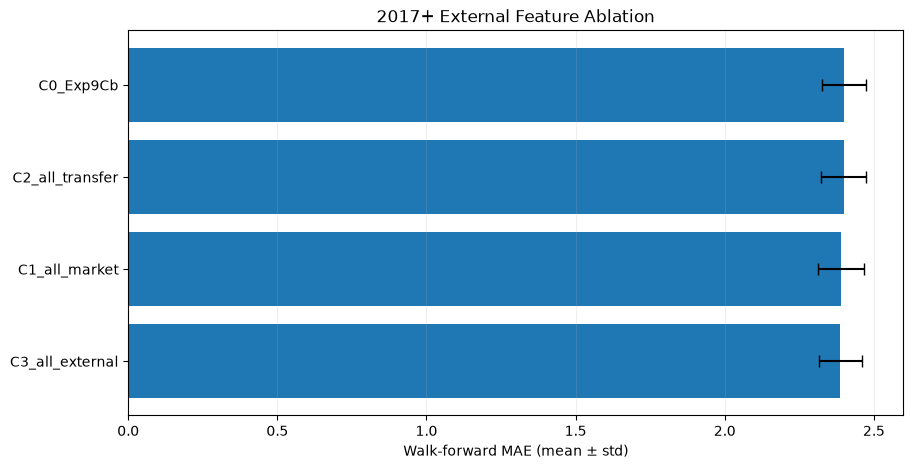

In [32]:
plot_df = (
    combined_summary
    .sort_values(
        "mae_mean",
        ascending=True,
    )
)

plt.figure(
    figsize=(10, 5)
)

plt.barh(
    plot_df[
        "experiment"
    ],
    plot_df[
        "mae_mean"
    ],
    xerr=plot_df[
        "mae_std"
    ],
    capsize=4,
)

plt.xlabel(
    "Walk-forward MAE "
    "(mean ± std)"
)

plt.title(
    "2017+ External Feature Ablation"
)

plt.grid(
    axis="x",
    alpha=0.2,
)

plt.show()

# Part H. Error Case 비교

## 27. Retegui / Greenwood / Guirassy / Dembélé

2017+ Combined prediction에서 기존 오류 사례가
외부 feature 추가 후 실제로 어떻게 변했는지 확인합니다.

In [33]:
CASE_PLAYERS = [
    "Mateo Retegui",
    "Mason Greenwood",
    "Serhou Guirassy",
    "Ousmane Dembélé",
]

case_predictions = (
    combined_predictions[
        combined_predictions[
            "player"
        ].isin(
            CASE_PLAYERS
        )
    ]
    .copy()
)

case_predictions[
    "error"
] = (
    case_predictions[
        "prediction"
    ]
    - case_predictions[
        "next_goals"
    ]
)

case_predictions[
    "abs_error"
] = (
    case_predictions[
        "error"
    ]
    .abs()
)

display(
    case_predictions[
        [
            "player",
            "season",
            "target_season",
            "team",
            "destination_team",
            "changed_team_preseason",
            "market_value_preseason_eur",
            "next_goals",
            "experiment",
            "prediction",
            "error",
            "abs_error",
        ]
    ]
    .sort_values(
        [
            "player",
            "season",
            "experiment",
        ]
    )
)

,player,season,target_season,team,destination_team,changed_team_preseason,market_value_preseason_eur,next_goals,experiment,prediction,error,abs_error
503,Mason Greenwood,2020-2021,2021-2022,Manchester Utd,Manchester Utd,0,50000000.0,5.0,C0_Exp9Cb,6.993465,1.993465,1.993465
1337,Mason Greenwood,2020-2021,2021-2022,Manchester Utd,Manchester Utd,0,50000000.0,5.0,C1_all_market,7.543205,2.543205,2.543205
2171,Mason Greenwood,2020-2021,2021-2022,Manchester Utd,Manchester Utd,0,50000000.0,5.0,C2_all_transfer,7.337162,2.337162,2.337162
3005,Mason Greenwood,2020-2021,2021-2022,Manchester Utd,Manchester Utd,0,50000000.0,5.0,C3_all_external,7.283510,2.283510,2.283510
9878,Mason Greenwood,2023-2024,2024-2025,Getafe,Olympique Marseille,1,25000000.0,21.0,C0_Exp9Cb,7.221972,-13.778028,13.778028
10647,Mason Greenwood,2023-2024,2024-2025,Getafe,Olympique Marseille,1,25000000.0,21.0,C1_all_market,6.925387,-14.074613,14.074613
11416,Mason Greenwood,2023-2024,2024-2025,Getafe,Olympique Marseille,1,25000000.0,21.0,C2_all_transfer,6.453277,-14.546723,14.546723
12185,Mason Greenwood,2023-2024,2024-2025,Getafe,Olympique Marseille,1,25000000.0,21.0,C3_all_external,6.762641,-14.237359,14.237359
9880,Mateo Retegui,2023-2024,2024-2025,Genoa,Atalanta BC,1,16000000.0,25.0,C0_Exp9Cb,4.751929,-20.248071,20.248071
10649,Mateo Retegui,2023-2024,2024-2025,Genoa,Atalanta BC,1,16000000.0,25.0,C1_all_market,4.895064,-20.104936,20.104936


# Part I. 결과 저장

## 28. CSV 저장

In [34]:
ARTIFACT_DIR = Path(
    "artifacts"
)

ARTIFACT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

OUTPUTS = {
    "fold_results": (
        ARTIFACT_DIR
        / "08_02_external_ablation_fold_results.csv"
    ),

    "summary": (
        ARTIFACT_DIR
        / "08_02_external_ablation_summary.csv"
    ),

    "improvement": (
        ARTIFACT_DIR
        / "08_02_external_ablation_improvement.csv"
    ),

    "predictions": (
        ARTIFACT_DIR
        / "08_02_external_ablation_predictions.csv"
    ),
}

all_fold_results.to_csv(
    OUTPUTS[
        "fold_results"
    ],
    index=False,
)

all_summary.to_csv(
    OUTPUTS[
        "summary"
    ],
    index=False,
)

improvement_df.to_csv(
    OUTPUTS[
        "improvement"
    ],
    index=False,
)

all_predictions.to_csv(
    OUTPUTS[
        "predictions"
    ],
    index=False,
)

print("Saved:")
for name, path in (
    OUTPUTS.items()
):
    print(
        f"- {name:<15}",
        path.resolve(),
    )

Saved:
- fold_results    D:\dev\03_PersonalProjects\next_season_goal_prediction\notebooks\artifacts\08_02_external_ablation_fold_results.csv
- summary         D:\dev\03_PersonalProjects\next_season_goal_prediction\notebooks\artifacts\08_02_external_ablation_summary.csv
- improvement     D:\dev\03_PersonalProjects\next_season_goal_prediction\notebooks\artifacts\08_02_external_ablation_improvement.csv
- predictions     D:\dev\03_PersonalProjects\next_season_goal_prediction\notebooks\artifacts\08_02_external_ablation_predictions.csv


## 29. 실험 정의 저장

후속 Notebook에서 feature 목록이 달라지는 것을 막기 위해
실험 정의를 JSON으로 같이 저장합니다.

In [35]:
EXPERIMENT_PROTOCOL = {
    "model": "Fixed Baseline CatBoost",
    "catboost_params": (
        FIXED_CATBOOST_PARAMS
    ),
    "outer_validation_seasons": (
        OUTER_VAL_SEASONS
    ),
    "market_min_target_year": 2005,
    "transfer_min_target_year": 2017,
    "test_status": (
        "LOCKED / NOT LOADED"
    ),
    "market_experiments": (
        MARKET_EXPERIMENTS
    ),
    "transfer_experiments": (
        TRANSFER_EXPERIMENTS
    ),
    "combined_experiments": (
        COMBINED_EXPERIMENTS
    ),
}

protocol_path = (
    ARTIFACT_DIR
    / "08_02_experiment_protocol.json"
)

with protocol_path.open(
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        EXPERIMENT_PROTOCOL,
        f,
        ensure_ascii=False,
        indent=2,
    )

print(
    "Saved:",
    protocol_path.resolve(),
)

Saved: D:\dev\03_PersonalProjects\next_season_goal_prediction\notebooks\artifacts\08_02_experiment_protocol.json


# 30. 결과 해석 — 직접 작성

아래 결론은 **의도적으로 비워둡니다.**

---

## A. Market 2005+

1. M1 Market Value가 M0보다 평균 MAE를 개선하는가?
2. 4개 Fold 중 몇 개에서 개선되는가?
3. Market Momentum까지 추가한 M2가 더 좋은가?
4. 고득점자 MAE / Bias가 개선되는가?
5. 시장가치가 전체 성능만 개선하고 high scorer는 그대로인가?

### 내 해석

- Market Value 효과:
- Market Momentum 추가 효과:
- 안정성:
- 유지할 feature:

---

## B. Transfer 2017+

1. T1 Transfer State가 T0보다 개선되는가?
2. T2 Economics가 추가 정보를 주는가?
3. T3 New-Team Environment가 도움이 되는가?
4. T4 전체 Transfer context가 가장 좋은가?
5. 전체 MAE보다 **changed_team_mae**에서 더 큰 개선이 나타나는가?
6. same-team 선수 성능을 해치지는 않는가?

### 내 해석

- Transfer State:
- Transfer Economics:
- New-Team Environment:
- 실제 이적 선수 성능:
- 유지할 feature:

---

## C. Combined 2017+

1. C1 Market-only와 C2 Transfer-only 중 무엇이 더 강한가?
2. C3 ALL External이 C0보다 개선되는가?
3. 개선이 4 Fold에서 반복되는가?
4. MAE std / worst Fold도 안정적인가?
5. 고득점자 과소예측이 완화되는가?
6. Retegui / Greenwood / Guirassy / Dembélé 사례는 어떻게 달라지는가?

### 내 최종 결론

- 전체 성능 기준 best:
- 고득점자 기준 best:
- 이적 선수 기준 best:
- 최종 유지할 Market feature:
- 최종 유지할 Transfer feature:
- 최종 유지할 New-Team feature:
- 재-HPO 필요 여부:
- CatBoost / MLP 재검증 필요 여부:
- 다음 단계:

# 다음 단계

08-02 결과에 따라 다음을 결정합니다.

## 외부 Feature가 유효할 경우

```text
Best External Feature Set
        ↓
CatBoost 재검증
        +
07 Tuned MLP 재검증
        ↓
필요할 경우 selected feature set에서만 HPO
```

이후:

```text
09 Model A
다음 시즌 Big5 기록 존재 여부 분류

09 Model B
matched_next 조건부 득점 회귀
```

로 확장합니다.

---

## 외부 Feature 효과가 작을 경우

그 결과 자체도 중요합니다.

그 경우 고득점자 문제의 다음 가설은:

- 출전시간 변화
- 역할 변화
- 페널티 전담
- 부상
- 감독/전술
- 동료 공격진 변화

등이 될 수 있습니다.

즉 **성능이 오르지 않아도 외부 데이터 가설을 검증했다는 점 자체가 결과**입니다.